In [4]:
import pandas as pd

# Input files
PROBE_ROWS_PATH = "/content/probe_results_rows.csv"
TOPUP_ROWS_PATH = "/content/probe_results_topup_rows.csv"

# Output file
OUT_PATH = "/content/probe_results_combined.csv"

TIME_COL_CANDIDATES = ["start_time_utc", "timestamp", "time", "created_at", "start_time", "ts"]


def pick_existing_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    raise ValueError(f"Could not find a time column. Found columns: {sorted(df.columns)}")


def parse_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


probe = pd.read_csv(PROBE_ROWS_PATH)
topup = pd.read_csv(TOPUP_ROWS_PATH)

probe_time_col = pick_existing_col(probe, TIME_COL_CANDIDATES)
topup_time_col = pick_existing_col(topup, TIME_COL_CANDIDATES)

probe[probe_time_col] = parse_utc(probe[probe_time_col])
topup[topup_time_col] = parse_utc(topup[topup_time_col])

probe = probe.loc[probe[probe_time_col].notna()].copy()
topup = topup.loc[topup[topup_time_col].notna()].copy()

if topup_time_col != probe_time_col:
    topup = topup.rename(columns={topup_time_col: probe_time_col})

time_col = probe_time_col

combined = pd.concat([probe, topup], ignore_index=True)
combined = combined.sort_values(time_col, kind="mergesort").reset_index(drop=True)

# Save
combined.to_csv(OUT_PATH, index=False)

print(f"Saved combined file to: {OUT_PATH}")
print(f"Rows in probe file: {len(probe)}")
print(f"Rows in topup file: {len(topup)}")
print(f"Rows in combined file: {len(combined)}")
print(f"Start time: {combined[time_col].min()}")
print(f"End time:   {combined[time_col].max()}")

Saved combined file to: /content/probe_results_combined.csv
Rows in probe file: 6412
Rows in topup file: 1099
Rows in combined file: 7511
Start time: 2026-02-07 02:53:13.958572+00:00
End time:   2026-02-19 04:14:17.608585+00:00


In [5]:
import argparse
import json
import warnings
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)


In [6]:
# ============================================================
# Config
# ============================================================
CSV_PATH = "/content/probe_results_combined.csv"

TIME_COL = "start_time_utc"
CREATED_COL = "created_at"
EVENT_TIME_COL = "event_time"

MAX_HOURS_PER_RUN = 5
TEST_FRACTION = 0.20
RANDOM_STATE = 42

ALPHA_PRIOR = 0.5
BETA_PRIOR = 2.0

POOL_COLS = ["provider", "region", "instance_type"]

TARGET_RATE_COL = "y_block_rate"
TARGET_COUNT_COL = "y_block_count"
TARGET_BIN_COL = "y_block_bin"
TARGET_HORIZON_COL = "y_block_horizon"

CALIB_FRACTION_WITHIN_TRAIN_FULL = 0.15

ECE_BINS = 20
EPS = 1e-15

EWMA_HALF_LIFE_H = 24.0
LAST24_WINDOW_H = 24.0
K_GRID = [0.0, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]
DELTA_CAP = 2.0

# ============================================================
# Actual fixed model parameters
# ============================================================
FIXED_ALPHA = 0.9838235589992128
FIXED_L2_REGULARIZATION = 0.8378401206547694
FIXED_MAX_DEPTH = 4
FIXED_MAX_LEAF_NODES = 5
FIXED_MIN_SAMPLES_LEAF = 649
FIXED_TEMP = 1.406058625756019

# ============================================================
# Decision setup
# ============================================================
TRAIN_MODEL_ON_LAUNCH_ONLY = True
DECISION_USE_LAUNCH_ONLY = True
PRICE_COL = "spot_price_usd"
REALIZED_POLICY_RISK_COL = TARGET_RATE_COL

DEFAULT_LAMBDA_GRID = [0.0, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

FIXED_BASELINE = {
    "east": {"c6i.large": 0.20, "m6a.large": 0.075, "t3a.large": 0.20},
    "west": {"c6i.large": 0.175, "m6a.large": 0.025, "t3a.large": 0.025},
}

RUN_ID_COL = "run_id"


In [13]:
# ============================================================
# Helpers / metrics
# ============================================================
def safe_parse_dt(s):
    try:
        return pd.to_datetime(s, utc=True)
    except Exception:
        return pd.NaT


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)
    m = (z >= 0)
    out[m] = 1.0 / (1.0 + np.exp(-z[m]))
    ez = np.exp(z[~m])
    out[~m] = ez / (1.0 + ez)
    return out


def logit(p, eps=EPS):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def brier_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean((p - y) ** 2))


def mae_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean(np.abs(p - y)))


def log_loss_fractional(y_true, p_pred, eps=EPS):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), eps, 1.0 - eps)
    ll = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return float(np.mean(ll))


def ece_score(y_true, p_pred, n_bins=20):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)

    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    bin_ids = np.minimum(np.digitize(p, edges, right=False) - 1, n_bins - 1)
    bin_ids = np.maximum(bin_ids, 0)

    ece = 0.0
    n_total = len(y)

    for b in range(n_bins):
        m = (bin_ids == b)
        n_b = int(np.sum(m))
        if n_b == 0:
            continue
        pred_b = float(np.mean(p[m]))
        true_b = float(np.mean(y[m]))
        ece += (n_b / max(1, n_total)) * abs(pred_b - true_b)

    return float(ece)


def auc_safe(y_bin, p_pred):
    try:
        return float(roc_auc_score(np.asarray(y_bin, int), np.asarray(p_pred, float)))
    except Exception:
        return float("nan")


def apply_temperature(p, temp):
    z = logit(p, eps=EPS)
    z = z / float(max(1e-9, temp))
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def print_metrics_block(title, y_rate, y_bin, p_model, global_q, extra_baselines=None):
    y_rate = np.asarray(y_rate, float)
    y_bin = np.asarray(y_bin, int)
    p_model = np.asarray(p_model, float)

    p0 = np.zeros_like(p_model)
    pg = np.full_like(p_model, float(np.clip(global_q, EPS, 1.0 - EPS)))

    rows = [
        ("model", p_model),
        ("global_avg", pg),
        ("always_0", p0),
    ]

    if extra_baselines:
        for name, p in extra_baselines.items():
            p = np.asarray(p, float)
            if len(p) == len(p_model):
                rows.append((str(name), np.clip(p, EPS, 1.0 - EPS)))

    print("\n==============================")
    print(title)
    print("==============================")
    for name, p in rows:
        print(
            f"{name:<14} -> "
            f"Brier: {brier_fractional(y_rate, p):.6f} | "
            f"LogLoss: {log_loss_fractional(y_rate, p):.6f} | "
            f"MAE: {mae_fractional(y_rate, p):.6f} | "
            f"ECE: {ece_score(y_rate, p, n_bins=ECE_BINS):.6f} | "
            f"AUC: {auc_safe(y_bin, np.clip(p, 0, 1)):.3f}"
        )


# ============================================================
# Fixed lookup baseline helpers
# ============================================================
def _norm_region_bucket(region):
    r = str(region).strip().lower()
    if "east" in r:
        return "east"
    if "west" in r:
        return "west"
    return None


def fixed_lookup_prob(region, instance_type, fallback):
    bucket = _norm_region_bucket(region)
    it = str(instance_type).strip().lower()
    if bucket is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    p = FIXED_BASELINE.get(bucket, {}).get(it, None)
    if p is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    return float(np.clip(p, EPS, 1.0 - EPS))


def fixed_lookup_series(df, fallback):
    return np.array(
        [fixed_lookup_prob(r, it, fallback) for r, it in zip(df["region"].values, df["instance_type"].values)],
        dtype=float,
    )


# ============================================================
# Pool-specific global average helpers
# ============================================================
def build_pool_global_avg_lookup(train_df, fallback):
    """
    Build a per-pool historical average risk lookup from training data.
    This is the 'global average of the particular pool' baseline.
    """
    grp = train_df.groupby(POOL_COLS, dropna=False)

    lookup = {}
    for key, g in grp:
        numer = float(g[TARGET_COUNT_COL].sum() + ALPHA_PRIOR)
        denom = float(g[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR)
        p = numer / max(denom, 1e-12)
        key_str = tuple(str(x) for x in key)
        lookup[key_str] = float(np.clip(p, EPS, 1.0 - EPS))

    return lookup, float(np.clip(fallback, EPS, 1.0 - EPS))


def pool_global_avg_series(df, lookup, fallback):
    vals = []
    for _, r in df.iterrows():
        key = tuple(str(r[c]) for c in POOL_COLS)
        vals.append(lookup.get(key, fallback))
    return np.array(vals, dtype=float)


# ============================================================
# Load data
# ============================================================
def load_raw(path):
    df = pd.read_csv(path)
    print(f"Loaded rows: {len(df)}")

    df = df.reset_index(drop=True).copy()
    df[RUN_ID_COL] = np.arange(len(df), dtype=np.int64)

    if TIME_COL in df.columns:
        df[TIME_COL] = df[TIME_COL].apply(safe_parse_dt)
    if CREATED_COL in df.columns:
        df[CREATED_COL] = df[CREATED_COL].apply(safe_parse_dt)

    if "features_snapshot" in df.columns:
        def unpack_json(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            try:
                return json.loads(x)
            except Exception:
                return {}

        fs = df["features_snapshot"].apply(unpack_json)
        df["fs_launch_local_hour"] = fs.apply(lambda d: d.get("launch_local_hour", np.nan))
        df["fs_launch_utc_hour"] = fs.apply(lambda d: d.get("launch_utc_hour", np.nan))
        df["fs_launch_dow"] = fs.apply(lambda d: d.get("launch_dow", np.nan))
        df["fs_price_zscore_6h"] = fs.apply(lambda d: d.get("price_zscore_6h", np.nan))

    out_norm = df.get("outcome", "").astype(str).str.strip().str.lower()
    df["is_launch_failed_int"] = out_norm.str.contains("launchfailed", na=False).astype(int)

    for c in POOL_COLS:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    if PRICE_COL not in df.columns:
        df[PRICE_COL] = np.nan
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")

    return df


# ============================================================
# Slice construction
# ============================================================
def make_hour_slices(df):
    need = [TIME_COL, "duration_minutes", "interrupted", RUN_ID_COL]
    for c in need:
        if c not in df.columns:
            df[c] = np.nan

    launched_mask = df["is_launch_failed_int"] == 0
    elig = df[launched_mask & df[TIME_COL].notna()].copy()

    rows = []
    for _, r in elig.iterrows():
        t0 = r[TIME_COL]
        dur = r.get("duration_minutes", np.nan)
        intr = bool(r.get("interrupted", False))
        rid = r.get(RUN_ID_COL)

        if pd.isna(dur):
            continue

        total_minutes = float(dur)
        max_slices = int(np.ceil(min(total_minutes, MAX_HOURS_PER_RUN * 60) / 60.0))
        if max_slices <= 0:
            continue

        for k in range(max_slices):
            slice_start = t0 + pd.Timedelta(hours=k)
            lo = k * 60.0
            hi = (k + 1) * 60.0

            if intr and (lo < total_minutes <= hi):
                y = 1
            elif total_minutes > hi or (not intr and total_minutes >= hi):
                y = 0
            else:
                continue

            row = r.to_dict()
            row[EVENT_TIME_COL] = slice_start
            row["slice_k"] = k
            row["y_1h"] = y
            row[RUN_ID_COL] = rid
            rows.append(row)

    return pd.DataFrame(rows)


def add_time_features(d):
    d = d.copy()
    dt = pd.to_datetime(d[EVENT_TIME_COL], utc=True)

    hour = dt.dt.hour.astype(float)
    dow = dt.dt.weekday.astype(float)

    d["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    d["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    d["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    d["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)

    d["is_weekend"] = (dt.dt.weekday >= 5).astype(int)

    h_int = dt.dt.hour.astype(int).values
    tod = np.zeros(len(d), dtype=int)
    tod[(h_int >= 6) & (h_int < 12)] = 1
    tod[(h_int >= 12) & (h_int < 18)] = 2
    tod[(h_int >= 18) & (h_int < 24)] = 3
    d["tod_bin"] = tod

    return d


# ============================================================
# Split logic
# ============================================================
def time_split_by_run_with_gap(d_slices, test_fraction=0.2, block_hours=6):
    df = d_slices.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    g = df.groupby(RUN_ID_COL, sort=False)
    run_min = g[EVENT_TIME_COL].min()
    run_max = g[EVENT_TIME_COL].max()

    runs = pd.DataFrame({
        RUN_ID_COL: run_min.index.values,
        "run_min_t": pd.to_datetime(run_min.values, utc=True),
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    }).sort_values("run_min_t").reset_index(drop=True)

    if len(runs) < 10:
        raise ValueError("Too few runs after slicing to split reliably.")

    split_idx = int((1.0 - float(test_fraction)) * len(runs))
    split_idx = min(max(split_idx, 1), len(runs) - 2)
    split_time = pd.to_datetime(runs.loc[split_idx, "run_min_t"], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    train_end_time = split_time - gap

    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    test_run_ids = runs.loc[runs["run_min_t"] > split_time, RUN_ID_COL].values

    train_full = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)
    test = df[df[RUN_ID_COL].isin(test_run_ids)].copy().reset_index(drop=True)

    dropped = len(runs) - (len(train_run_ids) + len(test_run_ids))
    print(
        f"✅ Run-split sizes: train_full={len(train_full)} test={len(test)} "
        f"(gap={block_hours}h, dropped_runs={dropped})"
    )

    if len(train_full) == 0 or len(test) == 0:
        raise ValueError("Empty train_full or test after enforcing run-split + gap.")

    return train_full, test


def split_train_full_into_core_gap_calib(train_full_raw, block_hours, calib_frac=0.15):
    df = train_full_raw.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    n = len(df)
    n_cal = int(np.ceil(calib_frac * n))
    n_cal = max(1, min(n_cal, n - 1))

    calib_start_idx = n - n_cal
    calib_start_time = pd.to_datetime(df.loc[calib_start_idx, EVENT_TIME_COL], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    core_end_time = calib_start_time - gap

    t = pd.to_datetime(df[EVENT_TIME_COL], utc=True)
    train_core_raw = df[t <= core_end_time].copy().reset_index(drop=True)
    calib_raw = df[t >= calib_start_time].copy().reset_index(drop=True)

    print(f"Train_full split (gap={block_hours}h): train_core={len(train_core_raw)} calib={len(calib_raw)}")

    if len(train_core_raw) == 0 or len(calib_raw) == 0:
        raise ValueError("Empty train_core or calib after enforcing core/calib gap.")

    return train_core_raw, calib_raw


# ============================================================
# Target construction
# ============================================================
def add_pool_block_rate_target_within_df(d, block_hours):
    d = d.copy().reset_index(drop=True)
    d = d.sort_values(POOL_COLS + [EVENT_TIME_COL]).reset_index(drop=True)

    times = pd.to_datetime(d[EVENT_TIME_COL], utc=True).values
    y1 = d["y_1h"].astype(int).values

    n = len(d)
    y_block_count = np.zeros(n, dtype=float)
    y_block_horizon = np.zeros(n, dtype=float)
    H = pd.Timedelta(hours=block_hours)

    grp = d.groupby(POOL_COLS, sort=False, group_keys=False)
    for _, idx in grp.groups.items():
        idx_arr = np.asarray(idx, dtype=int)
        t_pool = times[idx_arr]
        y_pool = y1[idx_arr]
        L = len(idx_arr)
        cum = np.concatenate([[0], np.cumsum(y_pool)])

        e = 0
        for i in range(L):
            t_end = t_pool[i] + H
            while e < L and t_pool[e] < t_end:
                e += 1
            y_block_horizon[idx_arr[i]] = float(e - i)
            y_block_count[idx_arr[i]] = float(cum[e] - cum[i])

    with np.errstate(divide="ignore", invalid="ignore"):
        y_block_rate = np.where(y_block_horizon > 0, y_block_count / y_block_horizon, 0.0)

    d[TARGET_COUNT_COL] = y_block_count
    d[TARGET_RATE_COL] = y_block_rate
    d[TARGET_BIN_COL] = (y_block_count > 0).astype(int)
    d[TARGET_HORIZON_COL] = y_block_horizon

    return d.sort_values(EVENT_TIME_COL).reset_index(drop=True)


def compute_global_q(train_df):
    return float(
        (train_df[TARGET_COUNT_COL].sum() + ALPHA_PRIOR)
        / (train_df[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR)
    )


# ============================================================
# Online EWMA
# ============================================================
def ewma_alpha(half_life_h, dt_h):
    lam = np.log(2.0) / float(max(1e-9, half_life_h))
    a = 1.0 - np.exp(-lam * float(max(0.0, dt_h)))
    return float(np.clip(a, 0.0, 1.0))


class OnlineEWMA:
    def __init__(self, half_life_h=24.0):
        self.half_life_h = float(half_life_h)
        self.mu = {}
        self.neff = {}
        self.last_t = {}

    def update_one(self, key, t_now, y):
        t_now = pd.to_datetime(t_now, utc=True)
        y = float(np.clip(y, 0.0, 1.0))

        if key not in self.mu:
            self.mu[key] = y
            self.neff[key] = 1.0
            self.last_t[key] = t_now
            return

        dt_h = float((t_now - self.last_t[key]) / np.timedelta64(1, "h"))
        dt_h = max(0.0, min(dt_h, 168.0))
        a = ewma_alpha(self.half_life_h, dt_h)

        self.mu[key] = (1.0 - a) * self.mu[key] + a * y
        self.neff[key] = (1.0 - a) * self.neff[key] + 1.0
        self.last_t[key] = t_now

    def get(self, key):
        if key not in self.mu:
            return None, 0.0
        return float(self.mu[key]), float(self.neff[key])


def build_online_ewma_features(df_seq, block_hours, global_fallback):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)

    pending = deque()
    base_pool = np.zeros(len(df), float)
    base_glob = np.zeros(len(df), float)
    neff_pool = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(df.loc[j, TARGET_RATE_COL])
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_fallback

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)

        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        base_pool[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))
        base_glob[i] = float(np.clip(mu_g, EPS, 1.0 - EPS))
        neff_pool[i] = float(max(0.0, ne_p))

    return base_pool, base_glob, neff_pool


def shrink_pool_to_global(mu_p, mu_g, ne_p, K):
    ne_p = float(max(0.0, ne_p))
    K = float(max(0.0, K))
    w = 0.0 if (ne_p + K) <= 1e-12 else (ne_p / (ne_p + K))
    return float(np.clip(w * mu_p + (1.0 - w) * mu_g, EPS, 1.0 - EPS))


# ============================================================
# Online last-24h baseline
# ============================================================
class OnlineWindowMean:
    def __init__(self, window_h=24.0):
        self.window_h = float(window_h)
        self.q = {}
        self.sumy = {}
        self.cnt = {}

    def _ensure(self, key):
        if key not in self.q:
            self.q[key] = deque()
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def add(self, key, t, y):
        self._ensure(key)
        t = pd.to_datetime(t, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        self.q[key].append((t, y))
        self.sumy[key] += y
        self.cnt[key] += 1

    def prune(self, key, t_ref):
        if key not in self.q:
            return

        t_ref = pd.to_datetime(t_ref, utc=True)
        cutoff = t_ref - pd.Timedelta(hours=float(self.window_h))
        dq = self.q[key]

        while dq and dq[0][0] <= cutoff:
            _, y0 = dq.popleft()
            self.sumy[key] -= float(y0)
            self.cnt[key] -= 1

        if self.cnt[key] <= 0:
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def mean_and_count(self, key, t_ref):
        self._ensure(key)
        self.prune(key, t_ref)
        if self.cnt[key] <= 0:
            return None, 0
        return float(self.sumy[key] / max(1, self.cnt[key])), int(self.cnt[key])


def build_last24_baseline_prequential(df_seq, block_hours, global_fallback, window_h=24.0):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values
    y = df[TARGET_RATE_COL].astype(float).values

    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()

    p_last24 = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        release_cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= release_cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(y[j], 0.0, 1.0))
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())

            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g is None:
            mu_g = float(global_fallback)

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p is None:
            mu_p = float(mu_g)

        p_last24[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

    return p_last24


# ============================================================
# ML model
# ============================================================
def feature_lists():
    cat_all = ["provider", "region", "instance_type"]
    num_all = [
        "slice_k",
        "sin_hour", "cos_hour", "sin_dow", "cos_dow",
        "is_weekend",
        PRICE_COL,
        "fs_price_zscore_6h",
        "fs_launch_local_hour", "fs_launch_utc_hour",
        "tod_bin",
        "pool_neff",
        "p_base",
    ]
    return cat_all, num_all


def ensure_feature_columns(df, feat_cols):
    out = df.copy()
    for c in feat_cols:
        if c not in out.columns:
            out[c] = np.nan
    return out


def build_X(df, feat_cols, cat_cols, columns_like=None):
    work = ensure_feature_columns(df, feat_cols)
    X = pd.get_dummies(work[feat_cols].copy(), columns=cat_cols, dummy_na=True)
    if columns_like is not None:
        X = X.reindex(columns=columns_like, fill_value=0.0)
    return X


def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=FIXED_MAX_DEPTH,
        max_leaf_nodes=FIXED_MAX_LEAF_NODES,
        learning_rate=0.03,
        max_iter=1200,
        min_samples_leaf=FIXED_MIN_SAMPLES_LEAF,
        l2_regularization=FIXED_L2_REGULARIZATION,
        random_state=RANDOM_STATE,
    )


def predict_delta(m, X):
    d = m.predict(X)
    d = np.where(np.isfinite(d), d, 0.0)
    return np.clip(d, -DELTA_CAP, DELTA_CAP)


def p_from_base_and_delta(p_base, delta_hat):
    z = logit(p_base, eps=EPS) + delta_hat
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def mix_probs(p_base, p_ml, alpha):
    a = float(np.clip(alpha, 0.0, 1.0))
    return np.clip((1.0 - a) * p_base + a * p_ml, EPS, 1.0 - EPS)


# ============================================================
# Filtering
# ============================================================
def filter_launch_only(df):
    if "slice_k" not in df.columns:
        return df.copy()
    return df[df["slice_k"].astype(int) == 0].copy().reset_index(drop=True)


# ============================================================
# Decision table
# ============================================================
def _ensure_price(df):
    if PRICE_COL not in df.columns:
        df[PRICE_COL] = np.nan
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")
    return df


def make_decision_table_from_test(test_rows, block_hours):
    df = test_rows.copy()
    df = _ensure_price(df)

    df["decision_time"] = pd.to_datetime(df[EVENT_TIME_COL], utc=True).dt.floor("h")

    if DECISION_USE_LAUNCH_ONLY:
        df = filter_launch_only(df)

    need = ["decision_time", PRICE_COL, REALIZED_POLICY_RISK_COL, TARGET_BIN_COL] + POOL_COLS
    for c in need:
        if c not in df.columns:
            raise ValueError(f"Decision backtest missing required column: {c}")

    risk_cols = [
        "p_hat",
        "p_ml_only",
        "p_ewma_only",
        "p_last24",
        "p_fixed_map",
        "p_global_avg",
        "p_always_0",
    ]

    agg = {
        PRICE_COL: "mean",
        REALIZED_POLICY_RISK_COL: "mean",
        TARGET_BIN_COL: "mean",
        RUN_ID_COL: "count",
    }
    for c in risk_cols:
        if c in df.columns:
            agg[c] = "mean"

    cand = (
        df.groupby(["decision_time"] + POOL_COLS, as_index=False)
        .agg(agg)
        .rename(columns={
            RUN_ID_COL: "n_runs",
            REALIZED_POLICY_RISK_COL: "realized_policy_risk",
            TARGET_BIN_COL: "realized_block_bin",
        })
    )

    cand = cand[np.isfinite(cand[PRICE_COL].values)].copy()
    cand = cand.sort_values("decision_time").reset_index(drop=True)

    print("\n==============================")
    print("Decision candidates built from TEST")
    print("==============================")
    print(f"block_hours={block_hours}  launch_only={DECISION_USE_LAUNCH_ONLY}")
    print(f"candidates={len(cand)}  unique_hours={cand['decision_time'].nunique()}")

    return cand


# ============================================================
# Policies
# ============================================================
RISK_SIGNAL_MAP = {
    "model": "p_hat",
    "ml_only": "p_ml_only",
    "ewma_only": "p_ewma_only",
    "last24_avg": "p_last24",
    "fixed_map": "p_fixed_map",
    "global_avg": "p_global_avg",
    "always_0": "p_always_0",
}


def select_pool_for_hour(cand_hour_df, strategy, rng=None, lambd=0.0):
    if len(cand_hour_df) == 0:
        return None
    if rng is None:
        rng = np.random.RandomState(RANDOM_STATE)

    if strategy == "price_only":
        return cand_hour_df.iloc[int(np.argmin(cand_hour_df[PRICE_COL].values))]

    if strategy == "random":
        return cand_hour_df.iloc[int(rng.randint(0, len(cand_hour_df)))]

    if strategy == "oracle":
        score = cand_hour_df[PRICE_COL].values + float(lambd) * cand_hour_df["realized_policy_risk"].values
        return cand_hour_df.iloc[int(np.argmin(score))]

    risk_col = RISK_SIGNAL_MAP.get(strategy)
    if risk_col is not None:
        if risk_col not in cand_hour_df.columns:
            raise ValueError(f"Missing risk signal for strategy {strategy}: {risk_col}")
        score = cand_hour_df[PRICE_COL].values + float(lambd) * cand_hour_df[risk_col].values
        return cand_hour_df.iloc[int(np.argmin(score))]

    raise ValueError(f"Unknown strategy: {strategy}")


def run_policy_backtest(candidates_df, lambda_grid, seed=RANDOM_STATE):
    df = candidates_df.sort_values("decision_time").reset_index(drop=True).copy()
    rng = np.random.RandomState(seed)

    strategies = [
        "model",
        "ml_only",
        "last24_avg",
        "ewma_only",
        "fixed_map",
        "global_avg",
        "price_only",
        "random",
        "oracle",
    ]

    grouped = list(df.groupby("decision_time", sort=True))
    if len(grouped) == 0:
        raise ValueError("No decision hours in candidates_df (after filtering).")

    out_rows = []
    for lambd in lambda_grid:
        for strat in strategies:
            chosen = []

            for _, cand_h in grouped:
                pick = select_pool_for_hour(
                    cand_h,
                    strategy=strat,
                    rng=rng,
                    lambd=float(lambd),
                )
                if pick is not None:
                    chosen.append(pick)

            ch = pd.DataFrame(chosen)

            avg_price = float(np.mean(ch[PRICE_COL].values))
            avg_real_risk = float(np.mean(ch["realized_policy_risk"].values))
            avg_real_bin = float(np.mean(ch["realized_block_bin"].values))
            avg_pred_risk_model = float(np.mean(ch["p_hat"].values)) if "p_hat" in ch.columns else float("nan")

            obj_real = ch[PRICE_COL].values + float(lambd) * ch["realized_policy_risk"].values

            out_rows.append({
                "strategy": strat,
                "lambda": float(lambd),
                "n_hours": int(len(ch)),
                "avg_price": avg_price,
                "avg_real_risk": avg_real_risk,
                "avg_real_bin": avg_real_bin,
                "avg_pred_risk_model": avg_pred_risk_model,
                "avg_objective_real": float(np.mean(obj_real)),
            })

    return pd.DataFrame(out_rows).sort_values(["lambda", "strategy"]).reset_index(drop=True)


def print_policy_summary(policy_df, top_k=10):
    print("\n==============================")
    print("Policy Backtest Summary (TEST)")
    print("==============================")

    for lambd, g in policy_df.groupby("lambda", sort=True):
        print(f"\n--- lambda = {float(lambd):.6g}  (objective = one_hour_price + lambda*risk_score) ---")
        g2 = g.sort_values("avg_objective_real").head(int(top_k))

        for _, r in g2.iterrows():
            print(
                f"{r['strategy']:<12} "
                f"hours={int(r['n_hours']):>5d}  "
                f"avg_price={r['avg_price']:.6f}  "
                f"avg_real_risk={r['avg_real_risk']:.6f}  "
                f"obj_real={r['avg_objective_real']:.6f}"
            )

        if len(g) > top_k:
            print(f"  ... ({len(g)-top_k} more strategies not shown)")


# ============================================================
# Plotting
# ============================================================
def plot_policy_results(policy_df, out_prefix=None, include_strategies=None):
    df = policy_df.copy()

    if include_strategies is not None:
        df = df[df["strategy"].isin(include_strategies)].copy()

    strategy_names = list(df["strategy"].unique())
    n_strategies = len(strategy_names)

    if n_strategies <= 20:
        cmap = plt.get_cmap("tab20")
        color_list = [cmap(i) for i in range(n_strategies)]
    else:
        cmap = plt.get_cmap("hsv")
        color_list = [cmap(i / n_strategies) for i in range(n_strategies)]

    strategy_to_color = {strat: color_list[i] for i, strat in enumerate(strategy_names)}

    plt.figure(figsize=(10, 6))
    for strat, g in df.groupby("strategy", sort=False):
        g = g.sort_values("lambda")
        plt.plot(
            g["lambda"],
            g["avg_objective_real"],
            marker="o",
            label=strat,
            color=strategy_to_color[strat],
        )
    plt.xscale("log")
    plt.xlabel("Risk-aversion λ (log scale)")
    plt.ylabel("Realized objective (one_hour_price + λ·realized_risk)")
    plt.title("Policy performance vs risk aversion")
    plt.legend(fontsize=8)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    if out_prefix:
        plt.savefig(f"{out_prefix}_objective_vs_lambda.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    for strat, g in df.groupby("strategy", sort=False):
        plt.scatter(
            g["avg_real_risk"],
            g["avg_price"],
            label=strat,
            color=strategy_to_color[strat],
        )
        for _, r in g.iterrows():
            plt.annotate(
                f"{r['lambda']}",
                (r["avg_real_risk"], r["avg_price"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=7,
            )
    plt.xlabel("Realized risk score (avg_real_risk)")
    plt.ylabel("Average one-hour spot price (avg_price)")
    plt.title("Price–risk tradeoff (points annotated by λ)")
    plt.legend(fontsize=8)
    plt.grid(True, linestyle="--", linewidth=0.5)
    if out_prefix:
        plt.savefig(f"{out_prefix}_price_risk_scatter.png", dpi=200, bbox_inches="tight")
    plt.show()


# ============================================================
# Main
# ============================================================
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--block-hours", type=int, default=6)
    parser.add_argument("--lambda-grid", type=str, default=",".join(map(str, DEFAULT_LAMBDA_GRID)))
    parser.add_argument("--out-prefix", type=str, default="policy_eval")
    args = parser.parse_args([])  # change to parser.parse_args() for CLI

    block_hours = int(args.block_hours)
    lambda_grid = [float(tok.strip()) for tok in str(args.lambda_grid).split(",") if tok.strip()]

    # ------------------------------------------------------------
    # Load and slice
    # ------------------------------------------------------------
    df_raw = load_raw(CSV_PATH)
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        print("No sliceable rows found.")
        return

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    # ------------------------------------------------------------
    # Split
    # ------------------------------------------------------------
    train_full_raw, test_raw = time_split_by_run_with_gap(d, TEST_FRACTION, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(
        train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL
    )

    # ------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------
    train_core = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    calib = add_pool_block_rate_target_within_df(calib_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core = train_core[train_core[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    calib = calib[calib[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    test = test[test[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)

    if TRAIN_MODEL_ON_LAUNCH_ONLY:
        train_core = filter_launch_only(train_core)
        calib = filter_launch_only(calib)
        test = filter_launch_only(test)
        print("\n[INFO] Using launch-only rows (slice_k == 0) for train/calib/test model pipeline.")

    global_q = compute_global_q(train_core)
    print(f"\nglobal_q (train_core) = {global_q:.6f}")

    train_core = train_core.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    calib = calib.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    # ------------------------------------------------------------
    # Build pool-specific global average lookup
    # ------------------------------------------------------------
    pool_global_avg_lookup, pool_global_avg_fallback = build_pool_global_avg_lookup(train_core, global_q)

    # ------------------------------------------------------------
    # EWMA features on train_core and calib
    # ------------------------------------------------------------
    tr_pool_mu, tr_glob_mu, tr_neff = build_online_ewma_features(train_core, block_hours, global_q)
    ca_pool_mu, ca_glob_mu, ca_neff = build_online_ewma_features(calib, block_hours, global_q)

    best_k = {"K": None, "brier": float("inf")}
    y_cal_rate = calib[TARGET_RATE_COL].astype(float).values

    for K in K_GRID:
        p_base = np.array([
            shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K)
            for i in range(len(calib))
        ])
        b = brier_fractional(y_cal_rate, p_base)
        if b < best_k["brier"]:
            best_k = {"K": float(K), "brier": float(b)}

    K_star = best_k["K"]
    print(f"\n[TUNED] best_K={K_star:.3f} on CALIB (baseline-only) with Brier={best_k['brier']:.6f}")

    train_core["pool_neff"] = tr_neff
    calib["pool_neff"] = ca_neff

    train_core["p_base"] = [
        shrink_pool_to_global(tr_pool_mu[i], tr_glob_mu[i], tr_neff[i], K_star)
        for i in range(len(train_core))
    ]
    calib["p_base"] = [
        shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K_star)
        for i in range(len(calib))
    ]

    train_core["p_ewma"] = np.clip(tr_pool_mu, EPS, 1.0 - EPS)
    calib["p_ewma"] = np.clip(ca_pool_mu, EPS, 1.0 - EPS)

    train_core["p_last24"] = build_last24_baseline_prequential(
        train_core, block_hours, global_q, window_h=LAST24_WINDOW_H
    )
    calib["p_last24"] = build_last24_baseline_prequential(
        calib, block_hours, global_q, window_h=LAST24_WINDOW_H
    )

    train_core["p_fixed"] = fixed_lookup_series(train_core, global_q)
    calib["p_fixed"] = fixed_lookup_series(calib, global_q)

    train_core["p_global_avg"] = pool_global_avg_series(train_core, pool_global_avg_lookup, pool_global_avg_fallback)
    calib["p_global_avg"] = pool_global_avg_series(calib, pool_global_avg_lookup, pool_global_avg_fallback)

    # ------------------------------------------------------------
    # Train residual model
    # ------------------------------------------------------------
    cat_cols, num_cols = feature_lists()
    feat_cols = cat_cols + num_cols

    train_core = ensure_feature_columns(train_core, feat_cols)
    calib = ensure_feature_columns(calib, feat_cols)
    test = ensure_feature_columns(test, feat_cols)

    X_core = build_X(train_core, feat_cols, cat_cols)
    master_cols = X_core.columns
    X_cal = build_X(calib, feat_cols, cat_cols, columns_like=master_cols)

    y_core = np.clip(train_core[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_core = np.clip(train_core["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_core = np.clip(logit(y_core) - logit(base_core), -DELTA_CAP, DELTA_CAP)

    model = make_model()
    model.fit(X_core, delta_core)

    alpha_star = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)

    print(
        f"\n[FIXED PARAMS] alpha={alpha_star:.12f}, temp={temp_star:.12f}, "
        f"max_depth={FIXED_MAX_DEPTH}, max_leaf_nodes={FIXED_MAX_LEAF_NODES}, "
        f"min_samples_leaf={FIXED_MIN_SAMPLES_LEAF}, l2_regularization={FIXED_L2_REGULARIZATION:.12f}"
    )

    # ------------------------------------------------------------
    # Warm start states from train_core + calib
    # ------------------------------------------------------------
    history = pd.concat([train_core, calib], axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)

    def warm_start_states(hist_df, block_hours_local):
        hist = hist_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
        tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

        ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
        ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
        wm_pool = OnlineWindowMean(LAST24_WINDOW_H)
        wm_glob = OnlineWindowMean(LAST24_WINDOW_H)

        pending = deque()
        for i in range(len(hist)):
            t_cur = pd.to_datetime(tvals[i], utc=True)
            pending.append(i)

            cutoff = t_cur - pd.Timedelta(hours=float(block_hours_local))
            while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
                j = pending.popleft()
                t_j = pd.to_datetime(tvals[j], utc=True)
                y_j = float(np.clip(hist.loc[j, TARGET_RATE_COL], 0.0, 1.0))
                k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())

                ew_pool.update_one(k, t_j, y_j)
                ew_glob.update_one(("__global__",), t_j, y_j)

                wm_pool.add(k, t_j, y_j)
                wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None and len(hist) > 0:
            ew_glob.mu[("__global__",)] = float(np.clip(global_q, EPS, 1.0 - EPS))
            ew_glob.neff[("__global__",)] = 0.0
            ew_glob.last_t[("__global__",)] = pd.to_datetime(hist[EVENT_TIME_COL].iloc[-1], utc=True)

        return ew_pool, ew_glob, wm_pool, wm_glob

    ew_pool, ew_glob, wm_pool, wm_glob = warm_start_states(history, block_hours)

    # ------------------------------------------------------------
    # TEST predictions
    # ------------------------------------------------------------
    test_sorted = test.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    test_sorted = _ensure_price(test_sorted)

    tvals = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).values
    pending = deque()

    p_hat = np.zeros(len(test_sorted), float)
    p_ml_only = np.zeros(len(test_sorted), float)
    p_ewma_only = np.zeros(len(test_sorted), float)
    p_last24 = np.zeros(len(test_sorted), float)

    for i in range(len(test_sorted)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(test_sorted.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            k_j = tuple(test_sorted.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(k_j, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

            wm_pool.add(k_j, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_q

        k_i = tuple(test_sorted.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        p_ewma_only[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

        mu_g24, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g24 is None:
            mu_g24 = float(global_q)

        mu_p24, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p24 is None:
            mu_p24 = float(mu_g24)

        p_last24[i] = float(np.clip(mu_p24, EPS, 1.0 - EPS))

        pool_neff_i = float(max(0.0, ne_p))
        p_base_i = shrink_pool_to_global(float(mu_p), float(mu_g), pool_neff_i, K_star)

        row = test_sorted.iloc[[i]].copy()
        row["pool_neff"] = pool_neff_i
        row["p_base"] = p_base_i
        row = ensure_feature_columns(row, feat_cols)

        X_i = build_X(row, feat_cols, cat_cols, columns_like=master_cols)

        d_hat = float(predict_delta(model, X_i)[0])
        p_ml_i = float(p_from_base_and_delta(p_base_i, d_hat))

        p_ml_only[i] = float(apply_temperature(np.array([np.clip(p_ml_i, EPS, 1.0 - EPS)]), temp_star)[0])
        p_mix_i = mix_probs(p_base_i, p_ml_i, alpha_star)
        p_hat[i] = float(apply_temperature(np.array([p_mix_i]), temp_star)[0])

    test_sorted["p_hat"] = p_hat
    test_sorted["p_ml_only"] = p_ml_only
    test_sorted["p_ewma_only"] = p_ewma_only
    test_sorted["p_last24"] = p_last24
    test_sorted["p_fixed_map"] = fixed_lookup_series(test_sorted, global_q)
    test_sorted["p_global_avg"] = pool_global_avg_series(test_sorted, pool_global_avg_lookup, pool_global_avg_fallback)
    test_sorted["p_always_0"] = 0.0

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------
    y_test = np.clip(test_sorted[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    y_test_bin = test_sorted[TARGET_BIN_COL].astype(int).values

    print_metrics_block(
        title=f"Metrics (TEST, launch-only risk model, block-{block_hours}h risk target)",
        y_rate=y_test,
        y_bin=y_test_bin,
        p_model=test_sorted["p_hat"].values,
        global_q=global_q,
        extra_baselines={
            "ml_only": test_sorted["p_ml_only"].values,
            "ewma_only": test_sorted["p_ewma_only"].values,
            "last24_avg": test_sorted["p_last24"].values,
            "fixed_map": test_sorted["p_fixed_map"].values,
            "pool_global_avg": test_sorted["p_global_avg"].values,
        },
    )

    # ------------------------------------------------------------
    # Policy backtest
    # ------------------------------------------------------------
    candidates = make_decision_table_from_test(test_sorted, block_hours)
    policy_res = run_policy_backtest(candidates, lambda_grid, seed=RANDOM_STATE)

    print_policy_summary(policy_res, top_k=10)

    print("\n==============================")
    print("Policy results table (copy/paste)")
    print("==============================")
    print(policy_res.to_string(index=False))

    plot_subset = [
        "model",
        "ml_only",
        "last24_avg",
        "ewma_only",
        "fixed_map",
        "global_avg",
        "price_only",
        "random",
        "oracle",
    ]
    plot_policy_results(policy_res, out_prefix=args.out_prefix, include_strategies=plot_subset)

    return {
        "train_core": train_core,
        "calib": calib,
        "test": test_sorted,
        "candidates": candidates,
        "policy_res": policy_res,
        "global_q": global_q,
        "K_star": K_star,
        "model": model,
    }

In [8]:
# ============================================================
# Extra summary plot from the separate plotting script
# ============================================================
def plot_mean_objective_bars(policy_df, wanted=None):
    if wanted is None:
        wanted = [
            "model",
            "last24_avg",
            "ewma_only",
            "fixed_map",
            "global_avg",
            "price_only",
            "random",
            "oracle",
        ]

    df = policy_df.copy()
    df = df[df["strategy"].isin(wanted)].copy()

    summary = (
        df.groupby("strategy", as_index=False)["avg_objective_real"]
          .mean()
          .rename(columns={"avg_objective_real": "mean_avg_objective_real"})
    )

    oracle_value = summary.loc[
        summary["strategy"] == "oracle", "mean_avg_objective_real"
    ].iloc[0]

    plot_df = (
        summary[summary["strategy"] != "oracle"]
        .sort_values("mean_avg_objective_real", ascending=True)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(12, 7))
    plt.bar(plot_df["strategy"], plot_df["mean_avg_objective_real"])

    plt.axhline(
        y=oracle_value,
        linestyle=":",
        linewidth=2,
        color="black",
        label=f"Oracle = {oracle_value:.4f}"
    )

    plt.ylabel("Mean Average Objective Across All Lambdas")
    plt.xlabel("Strategy")
    plt.title("Mean Average Objective by Strategy")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Bar values (sorted):")
    print(plot_df.to_string(index=False))
    print(f"\nOracle dotted-line value: {oracle_value:.6f}")

    return plot_df, oracle_value


Loaded rows: 7511
✅ Run-split sizes: train_full=5827 test=1502 (gap=6h, dropped_runs=182)
Train_full split (gap=6h): train_core=4775 calib=875

[INFO] Using launch-only rows (slice_k == 0) for train/calib/test model pipeline.

global_q (train_core) = 0.067138

[TUNED] best_K=0.000 on CALIB (baseline-only) with Brier=0.013655

[FIXED PARAMS] alpha=0.983823558999, temp=1.406058625756, max_depth=4, max_leaf_nodes=5, min_samples_leaf=649, l2_regularization=0.837840120655

Metrics (TEST, launch-only risk model, block-6h risk target)
model          -> Brier: 0.017553 | LogLoss: 0.241171 | MAE: 0.086844 | ECE: 0.023494 | AUC: 0.771
global_avg     -> Brier: 0.022625 | LogLoss: 0.281728 | MAE: 0.099220 | ECE: 0.013512 | AUC: 0.500
always_0       -> Brier: 0.028947 | LogLoss: 2.785544 | MAE: 0.080650 | ECE: 0.080650 | AUC: 0.500
ml_only        -> Brier: 0.017539 | LogLoss: 0.241047 | MAE: 0.086703 | ECE: 0.025321 | AUC: 0.771
ewma_only      -> Brier: 0.022210 | LogLoss: 0.276460 | MAE: 0.085019 

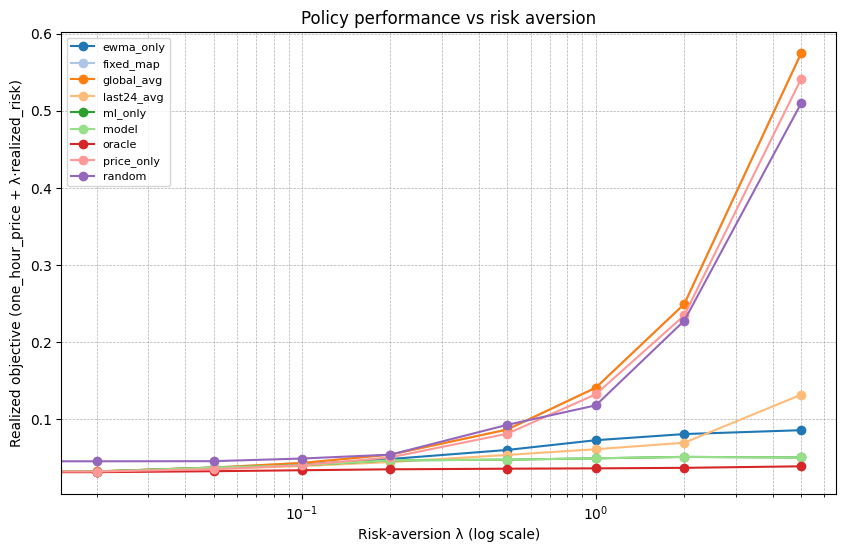

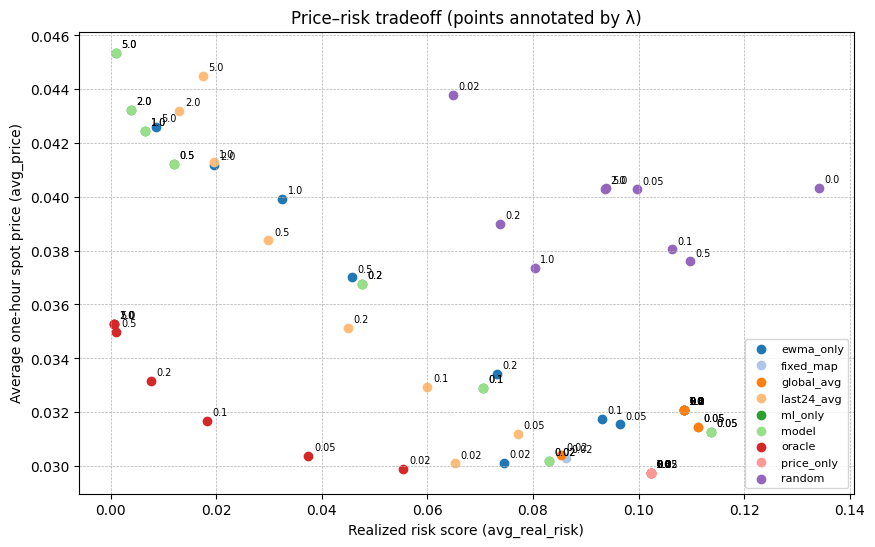

In [11]:
# Run the full policy evaluation pipeline
results = main()

# Convenience handles
policy_res = results["policy_res"]
test_scored = results["test"]
candidates = results["candidates"]


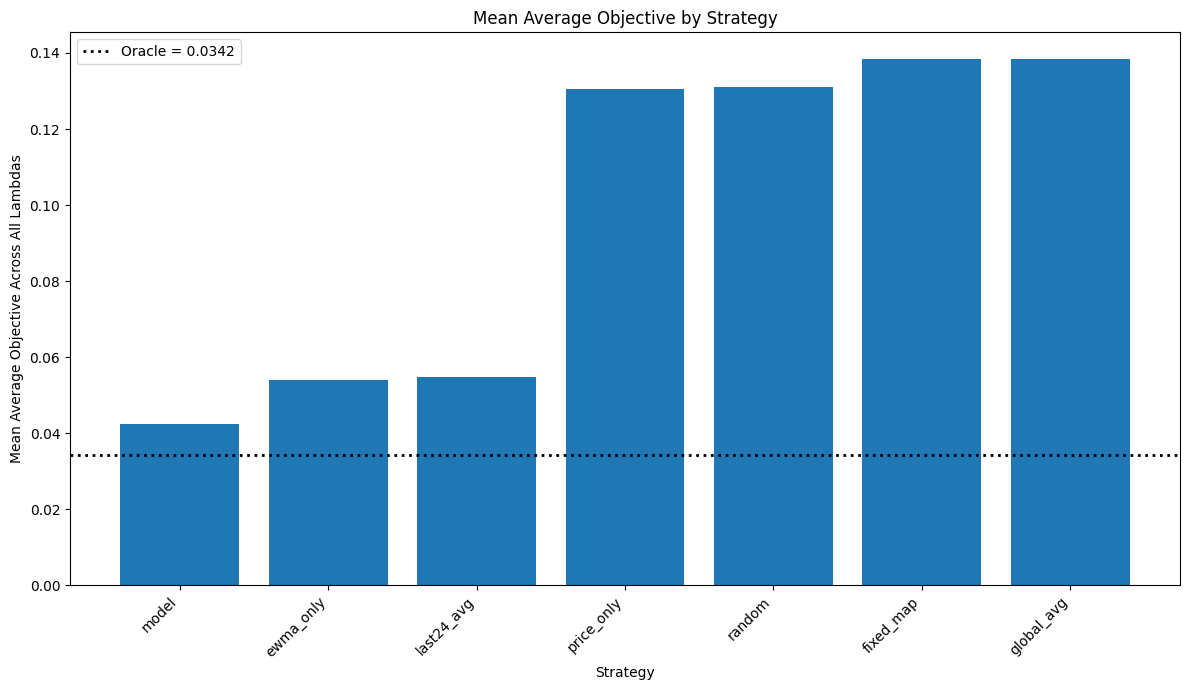

Bar values (sorted):
  strategy  mean_avg_objective_real
     model                 0.042423
 ewma_only                 0.053890
last24_avg                 0.054900
price_only                 0.130611
    random                 0.131169
 fixed_map                 0.138490
global_avg                 0.138497

Oracle dotted-line value: 0.034200


In [12]:
# Summary bar chart
plot_df, oracle_value = plot_mean_objective_bars(policy_res)
